# **CYBERBULLYING DETECTION ON TWITTER:ONE-STEP VS. TWO-STEP CLASSIFICATION**

### **IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('wordnet')
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import joblib
from google.colab import drive

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


### **EXPLORATORY DATA ANALYSIS**

In [ ]:
df = pd.read_csv("cyberbullying_tweets.csv")

In [ ]:
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [ ]:
df.shape

(47692, 2)

This dataset consists of 47,692 rows with 2 variables

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


Both variables, `tweet_text` and `cyberbullying_type`, are objects or strings

In [ ]:
df.isnull().sum()

,0
tweet_text,0
cyberbullying_type,0


There are no missing values in the dataset

#### **Label Distribution**

In [ ]:
df['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
religion,7998
age,7992
gender,7973
ethnicity,7961
not_cyberbullying,7945
other_cyberbullying,7823


In [ ]:
label_counts = df['cyberbullying_type'].value_counts()

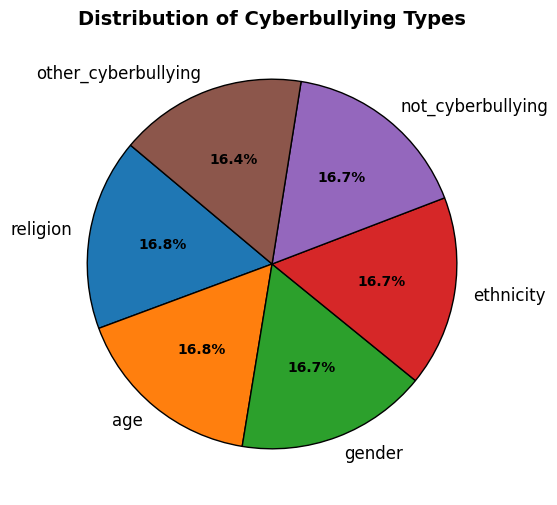

In [ ]:
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12},
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)
plt.setp(autotexts, size=10, weight="bold")
plt.title("Distribution of Cyberbullying Types", fontsize=14, weight='bold')
plt.show()

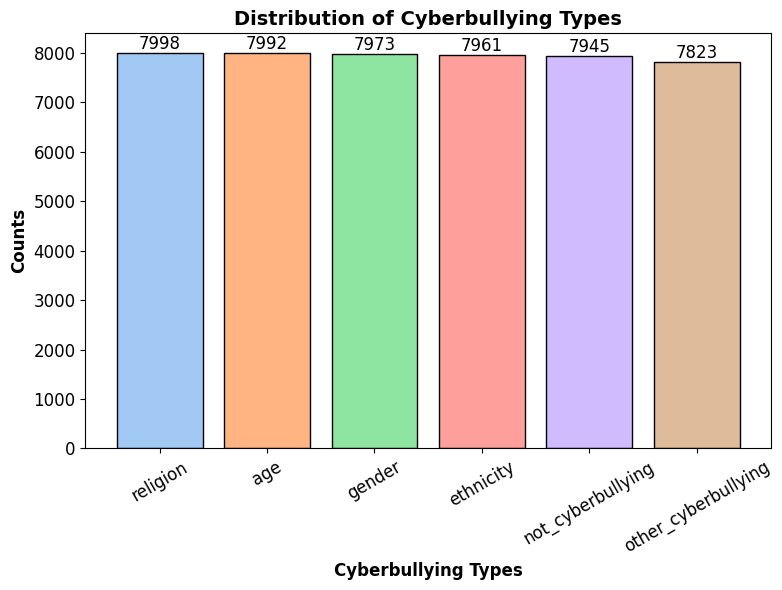

In [ ]:
colors = sns.color_palette("pastel", len(label_counts))

plt.figure(figsize=(8, 6))
plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')

plt.title("Distribution of Cyberbullying Types", fontsize=14, weight='bold')
plt.xlabel("Cyberbullying Types", fontsize=12, weight='bold')
plt.ylabel("Counts", fontsize=12, weight='bold')

for index, value in enumerate(label_counts.values):
    plt.text(index, value + max(label_counts.values) * 0.01, str(value), ha='center', fontsize=12)

plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

The `cyberbullying_type` label distribution is balanced

#### **Text Length and Word Count**

In [ ]:
df['text_length'] = df['tweet_text'].apply(len)
df['word_count'] = df['tweet_text'].apply(lambda x: len(x.split()))

In [ ]:
print("Average overall text length:")
print(df['text_length'].mean())

Average overall text length:
136.25322905309068


In [ ]:
print("Average text length of each label:")
print(df.groupby('cyberbullying_type')['text_length'].mean())

Average text length of each label:
cyberbullying_type
age                    173.542042
ethnicity              139.320060
gender                 136.422300
not_cyberbullying       83.107363
other_cyberbullying     85.713281
religion               197.999000
Name: text_length, dtype: float64


In [ ]:
print("Average overall word count:")
print(df['word_count'].mean())

Average overall word count:
23.704835192485113


In [ ]:
print("Average word count of each label:")
print(df.groupby('cyberbullying_type')['word_count'].mean())

Average word count of each label:
cyberbullying_type
age                    32.366366
ethnicity              24.889084
gender                 23.541452
not_cyberbullying      13.644682
other_cyberbullying    14.100345
religion               33.421730
Name: word_count, dtype: float64


#### **Most Frequent Words**

In [ ]:
vectorizer = CountVectorizer()
data_counts = vectorizer.fit_transform(df['tweet_text'])

word_counts = pd.DataFrame(data_counts.toarray(), columns=vectorizer.get_feature_names_out())

word_frequencies = word_counts.sum(axis=0).sort_values(ascending=False)

print("Top 20 Most Frequent Words Before Cleansing and Preprocessing:")
print(word_frequencies.head(20))

Top 20 Most Frequent Words Before Cleansing and Preprocessing:
the       31044
to        23614
and       21744
you       20641
of        15429
in        15029
is        14254
that      13140
it        12007
are        9229
school     8880
for        8722
me         7871
not        7456
my         6854
this       6761
was        6593
they       6491
but        6478
on         6232
dtype: int64


Most of the top frequents words are stop words

#### **Word Cloud**

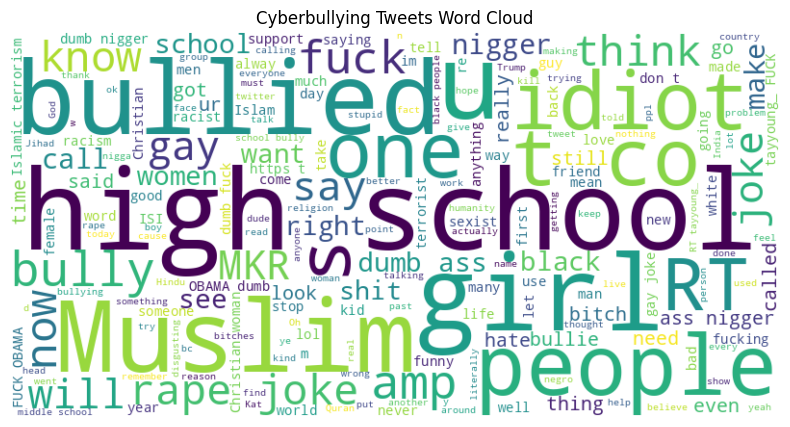

In [ ]:
all_text = " ".join(df['tweet_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Cyberbullying Tweets Word Cloud')
plt.show()

The word cloud above visualizes the most frequent words used in this dataset. It highlights hate speech with terms like "nigger," "fuck," "idiot," and "bitch". It also shows the targeting of marginalized groups, with words like "gay," "Muslim," "high school", and "girl".

## **ONE STEP CLASSIFICATION**

### **MODEL 1 - RAW DATA BEFORE CLEANSING AND PREPROCESSING**

In [ ]:
x = df['tweet_text']
y = df['cyberbullying_type']

Split the data into train and text with 80:20 ratio

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42,stratify=df['cyberbullying_type'])

All experiments use the same pipeline, with TF-IDF vectorizer and Random Forest classifier (default parameters)

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [ ]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipeline.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8162281161547332
Classification Report:
                      precision    recall  f1-score   support

                age       0.97      0.99      0.98      1598
          ethnicity       0.99      0.97      0.98      1592
             gender       0.92      0.83      0.87      1595
  not_cyberbullying       0.57      0.48      0.53      1589
other_cyberbullying       0.53      0.67      0.59      1565
           religion       0.95      0.95      0.95      1600

           accuracy                           0.82      9539
          macro avg       0.82      0.82      0.82      9539
       weighted avg       0.82      0.82      0.82      9539



### **CLEANSING**

In [ ]:
def clean_text(text):
    text = text.lower()  # Lowercase the text

    contractions = {
        "don't": "do not", "won't": "will not", "can't": "cannot",
        "i'm": "i am", "you're": "you are", "it's": "it is",
        "they're": "they are", "we're": "we are", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "haven't": "have not", "hasn't": "has not", "didn't": "did not",
        "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
        "doesn't": "does not", "mightn't": "might not", "mustn't": "must not"
    }

    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)

    text = re.sub(r"http\S+|www\S+|https\S+", "<URL>", text)  # Replace URL with placeholder
    text = re.sub(r"@\w+", "<MENTION>", text)  # Replace mentions with placeholder
    text = re.sub(r"\d+", " ", text)  # Delete numerics
    text = re.sub(r"[^\w\s#]", " ", text)  # Delete symbols except hashtag
    #text = re.sub(r"\b[a-zA-Z]\b", "", text)  # Delete single characters (example: "a", "b")
    text = re.sub(r"\s+", " ", text).strip()  # Delete extra spaces
    return text

In [ ]:
df['cleaned_text'] = df['tweet_text'].apply(clean_text)
df = df[df['cleaned_text'].str.strip() != '']

In [ ]:
df[['tweet_text','cleaned_text']].head()

,tweet_text,cleaned_text
0,"In other words #katandandre, your food was cra...",in other words #katandandre your food was crap...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is #aussietv so white #mkr #theblock #imac...
2,@XochitlSuckkks a classy whore? Or more red ve...,MENTION a classy whore or more red velvet cupc...
3,"@Jason_Gio meh. :P thanks for the heads up, b...",MENTION meh p thanks for the heads up but not ...
4,@RudhoeEnglish This is an ISIS account pretend...,MENTION this is an isis account pretending to ...


The `tweet_text` has been cleaned into `cleaned_text`

### **SPLITTING**

In [ ]:
x = df['cleaned_text']
y = df['cyberbullying_type']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42,stratify=df['cyberbullying_type'])

In [ ]:
print("X Train Data: ", x_train.shape)
print("X Test Data: ", x_test.shape)
print("Y Train Data: ", y_train.shape)
print("Y Test Data: ", y_test.shape)

X Train Data:  (38140,)
X Test Data:  (9535,)
Y Train Data:  (38140,)
Y Test Data:  (9535,)


### **MODEL 2 - AFTER CLEANSING**

In [ ]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipeline.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8099632931305716
Classification Report:
                      precision    recall  f1-score   support

                age       0.97      0.98      0.98      1598
          ethnicity       0.99      0.97      0.98      1592
             gender       0.91      0.81      0.86      1594
  not_cyberbullying       0.56      0.48      0.52      1589
other_cyberbullying       0.52      0.65      0.58      1562
           religion       0.96      0.95      0.95      1600

           accuracy                           0.81      9535
          macro avg       0.82      0.81      0.81      9535
       weighted avg       0.82      0.81      0.81      9535



The model accuracy after cleansing apparently decreased. Therefore, we need to do some preprocessing to increase its performance

### **ENCODING**

In [ ]:
df['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
religion,7998
age,7992
gender,7970
ethnicity,7961
not_cyberbullying,7944
other_cyberbullying,7810


In [ ]:
df['cyberbullying_type'] = df['cyberbullying_type'].map({'religion': 1, 'age': 2, 'gender': 3,
                                                         'ethnicity': 4, 'other_cyberbullying': 5, 'not_cyberbullying': 0})

In [ ]:
df['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
1,7998
2,7992
3,7970
4,7961
0,7944
5,7810


### **MODEL 3 - AFTER CLEANSING AND ENCODING**

In [ ]:
x = df['cleaned_text']
y = df['cyberbullying_type']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42,stratify=df['cyberbullying_type'])

In [ ]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipeline.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8102779234399581
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.48      0.52      1589
           1       0.96      0.94      0.95      1600
           2       0.96      0.98      0.97      1598
           3       0.92      0.81      0.86      1594
           4       0.99      0.98      0.98      1592
           5       0.52      0.67      0.59      1562

    accuracy                           0.81      9535
   macro avg       0.82      0.81      0.81      9535
weighted avg       0.82      0.81      0.81      9535



After cleansing and encoding, the accuracy is increased but still less than the raw data

### **PREPROCESSING**

#### **Extract Hashtag**

In [ ]:
def extract_hashtags(text):
    import re
    hashtags = re.findall(r"#\w+", text)
    return " ".join(hashtags) if hashtags else None

In [ ]:
x_train_hashtag = x_train.apply(extract_hashtags)
x_test_hashtag = x_test.apply(extract_hashtags)

x_train_pure = x_train.str.replace(r"#\w+", "", regex=True).str.strip()
x_test_pure = x_test.str.replace(r"#\w+", "", regex=True).str.strip()

In [ ]:
x_train_pure.head()

,cleaned_text
43868,cc MENTION MENTION racism is when u separate u...
20740,the guy you are responding to is an idiot but ...
25910,i miss my bully
12960,these two need to be in the dictionary under g...
25815,URL


In [ ]:
x_train_hashtag.head()

,cleaned_text
43868,None
20740,None
25910,None
12960,#mkr
25815,None


In [ ]:
x_test_pure.head()

,cleaned_text
9359,MENTION man ur a hypocrite u can make rape jok...
13725,notes no aids rape or racial jokes makes gay j...
39232,you are very ugly inside u hate this guy so mu...
23753,MENTION MENTION since islam has already declar...
24477,i agree dt rebecca blacks songs are kinda bad ...


In [ ]:
x_test_hashtag.head()

,cleaned_text
9359,None
13725,None
39232,None
23753,None
24477,None


#### **Tokenization**

In [ ]:
x_train_token =[word_tokenize(i) for i in x_train_pure]
x_test_token =[word_tokenize(i) for i in x_test_pure]

In [ ]:
print(x_train_token[0])
print(x_train_token[1])

['cc', 'MENTION', 'MENTION', 'racism', 'is', 'when', 'u', 'separate', 'ur', 'white', 'cloth', 'from', 'the', 'colored', 'once', 'while', 'washing', 'you', 're', 'all', 'racists']
['the', 'guy', 'you', 'are', 'responding', 'to', 'is', 'an', 'idiot', 'but', 'then', 'your', 'response', 'is', 'way', 'too', 'it', 'was', 'sort', 'of', 'like', 'an', 'atheist', 'watching', 'a', 'muslim', 'and', 'christian', 'debate']


In [ ]:
print(x_test_token[0])
print(x_test_token[1])

['MENTION', 'man', 'ur', 'a', 'hypocrite', 'u', 'can', 'make', 'rape', 'jokes', 'about', 'a', 'guy', 'being', 'afraid', 'of', 'a', 'gay', 'man', 'raping', 'him', 'but', 'tosh', 'can', 'not', 'shut', 'up', 'a', 'heckler']
['notes', 'no', 'aids', 'rape', 'or', 'racial', 'jokes', 'makes', 'gay', 'joke', 'shit']


#### **Lemmatization**

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

x_train_lemma = [lemmatize_tokens(tokens) for tokens in x_train_token]
x_test_lemma = [lemmatize_tokens(tokens) for tokens in x_test_token]

In [ ]:
print(x_train_lemma[0])
print(x_train_lemma[1])

['cc', 'MENTION', 'MENTION', 'racism', 'is', 'when', 'u', 'separate', 'ur', 'white', 'cloth', 'from', 'the', 'colored', 'once', 'while', 'washing', 'you', 're', 'all', 'racist']
['the', 'guy', 'you', 'are', 'responding', 'to', 'is', 'an', 'idiot', 'but', 'then', 'your', 'response', 'is', 'way', 'too', 'it', 'wa', 'sort', 'of', 'like', 'an', 'atheist', 'watching', 'a', 'muslim', 'and', 'christian', 'debate']


In [ ]:
print(x_test_lemma[0])
print(x_test_lemma[1])

['MENTION', 'man', 'ur', 'a', 'hypocrite', 'u', 'can', 'make', 'rape', 'joke', 'about', 'a', 'guy', 'being', 'afraid', 'of', 'a', 'gay', 'man', 'raping', 'him', 'but', 'tosh', 'can', 'not', 'shut', 'up', 'a', 'heckler']
['note', 'no', 'aid', 'rape', 'or', 'racial', 'joke', 'make', 'gay', 'joke', 'shit']


#### **Combine Lemmatized Text with Hashtag**

In [ ]:
x_train_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_train_lemma, x_train_hashtag)
]

# Combine x_test_lemma and x_test_hashtag
x_test_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_test_lemma, x_test_hashtag)
]

In [ ]:
print(x_train_combined[0])
print(x_train_combined[1])

cc MENTION MENTION racism is when u separate ur white cloth from the colored once while washing you re all racist 
the guy you are responding to is an idiot but then your response is way too it wa sort of like an atheist watching a muslim and christian debate 


In [ ]:
print(x_test_combined[0])
print(x_test_combined[1])

MENTION man ur a hypocrite u can make rape joke about a guy being afraid of a gay man raping him but tosh can not shut up a heckler 
note no aid rape or racial joke make gay joke shit 


### **MODEL 4 - AFTER PREPROCESSING WITHOUT STOPWORDS REMOVAL**

In [ ]:
pipeline.fit(x_train_combined, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipeline.predict(x_test_combined)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8144729942317777
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.50      0.53      1589
           1       0.96      0.94      0.95      1600
           2       0.98      0.97      0.98      1598
           3       0.91      0.83      0.87      1594
           4       0.99      0.98      0.99      1592
           5       0.53      0.66      0.58      1562

    accuracy                           0.81      9535
   macro avg       0.82      0.81      0.82      9535
weighted avg       0.82      0.81      0.82      9535



The accuracy now is also increased, but a bit less than the raw data. We will try to drop the stop words

#### **Stop Words Removal**

In [ ]:
stop_words = set(stopwords.words('english'))

list(stop_words)[:20]

['ma',
 'are',
 'themselves',
 'your',
 'same',
 'herself',
 'aren',
 'which',
 'won',
 'up',
 'over',
 'has',
 'was',
 'each',
 "hadn't",
 'during',
 'before',
 't',
 'where',
 'down']

In [ ]:
x_train_hashtag = x_train.apply(extract_hashtags)
x_test_hashtag = x_test.apply(extract_hashtags)

x_train_pure = x_train.str.replace(r"#\w+", "", regex=True).str.strip()
x_test_pure = x_test.str.replace(r"#\w+", "", regex=True).str.strip()

In [ ]:
x_train_token =[word_tokenize(i) for i in x_train_pure]
x_test_token =[word_tokenize(i) for i in x_test_pure]

In [ ]:
x_train_lemma = [lemmatize_tokens(tokens) for tokens in x_train_token]
x_test_lemma = [lemmatize_tokens(tokens) for tokens in x_test_token]

In [ ]:
# Remove stopwords from each sublist in word_token
x_train_filtered = [[word for word in sublist if word not in stop_words] for sublist in x_train_lemma]

In [ ]:
x_test_filtered = [[word for word in sublist if word not in stop_words] for sublist in x_test_lemma]

In [ ]:
print(x_train_filtered[0])
print(x_train_filtered[1])

['cc', 'MENTION', 'MENTION', 'racism', 'u', 'separate', 'ur', 'white', 'cloth', 'colored', 'washing', 'racist']
['guy', 'responding', 'idiot', 'response', 'way', 'wa', 'sort', 'like', 'atheist', 'watching', 'muslim', 'christian', 'debate']


In [ ]:
print(x_test_filtered[0])
print(x_test_filtered[1])

['MENTION', 'man', 'ur', 'hypocrite', 'u', 'make', 'rape', 'joke', 'guy', 'afraid', 'gay', 'man', 'raping', 'tosh', 'shut', 'heckler']
['note', 'aid', 'rape', 'racial', 'joke', 'make', 'gay', 'joke', 'shit']


#### **Combine Lemmatized Text with Hashtag**

In [ ]:
x_train_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_train_filtered, x_train_hashtag)
]

# Combine x_test_lemma and x_test_hashtag
x_test_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_test_filtered, x_test_hashtag)
]

In [ ]:
print(x_train_combined[0])
print(x_train_combined[1])

cc MENTION MENTION racism u separate ur white cloth colored washing racist 
guy responding idiot response way wa sort like atheist watching muslim christian debate 


In [ ]:
print(x_test_combined[0])
print(x_test_combined[1])

MENTION man ur hypocrite u make rape joke guy afraid gay man raping tosh shut heckler 
note aid rape racial joke make gay joke shit 


### **MODEL 5 - AFTER STOPWORDS REMOVAL**

In [ ]:
pipeline.fit(x_train_combined, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipeline.predict(x_test_combined)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8208704771893026
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.51      0.54      1589
           1       0.96      0.95      0.96      1600
           2       0.99      0.97      0.98      1598
           3       0.91      0.85      0.88      1594
           4       0.99      0.99      0.99      1592
           5       0.54      0.65      0.59      1562

    accuracy                           0.82      9535
   macro avg       0.83      0.82      0.82      9535
weighted avg       0.83      0.82      0.82      9535



After cleansing, encoding, stop word removal, and preprocessing, the accuracy is finally increased and higher than the raw data model. We will use this cleaned and preprocessed data for modeling.

### **VECTORIZER**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
pipeline_count = Pipeline([
    ('count_vect', CountVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [ ]:
from sklearn.feature_extraction.text import HashingVectorizer
pipeline_hash = Pipeline([
    ('hash_vect', HashingVectorizer(n_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [ ]:
pipeline_count.fit(x_train_combined, y_train)
y_pred = pipeline_count.predict(x_test_combined)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8200314630309387
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.53      0.55      1589
           1       0.97      0.94      0.96      1600
           2       0.99      0.97      0.98      1598
           3       0.89      0.85      0.87      1594
           4       0.99      0.99      0.99      1592
           5       0.55      0.63      0.58      1562

    accuracy                           0.82      9535
   macro avg       0.83      0.82      0.82      9535
weighted avg       0.83      0.82      0.82      9535



In [ ]:
pipeline_hash.fit(x_train_combined, y_train)
y_pred = pipeline_hash.predict(x_test_combined)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8192973256423702
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.50      0.53      1589
           1       0.97      0.95      0.96      1600
           2       0.99      0.97      0.98      1598
           3       0.91      0.85      0.88      1594
           4       0.99      0.98      0.99      1592
           5       0.53      0.66      0.59      1562

    accuracy                           0.82      9535
   macro avg       0.83      0.82      0.82      9535
weighted avg       0.83      0.82      0.82      9535



### **MODELING**

#### **Random Forest**

In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 300, 500],
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__min_samples_split': [2, 5, 10],
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    scoring='accuracy',
    cv=3,  # Cross-validation folds
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train_combined, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test_combined)
print("Accuracy on test data:", accuracy_score(y_test, y_pred_best))
print("Classification Report on test data:\n", classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
Best cross-validation score:  0.8308337748992912
Accuracy on test data: 0.8369166229680126
Classification Report on test data:
               precision    recall  f1-score   support

           0       0.65      0.52      0.58      1589
           1       0.96      0.95      0.96      1600
           2       0.98      0.98      0.98      1598
           3       0.90      0.84      0.87      1594
           4       0.99      0.99      0.99      1592
           5       0.58      0.75      0.65      1562

    accuracy                           0.84      9535
   macro avg       0.84      0.84      0.84      9535
weighted avg       0.84      0.84      0.84      9535



In [ ]:
joblib.dump(best_model, 'OC_best_rf_model.pkl')
print("Model saved as OC_best_rf_model.pkl")

Model saved as OC_best_rf_model.pkl


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/OC_best_rf_model.pkl'

# Save the best model
best_model_rf = joblib.load(model_path)
print("Model loaded successfully")

# Use saved model to make prediction
y_pred_rf = best_model_rf.predict(x_test_combined)
print("Accuracy on test data with loaded model:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:", classification_report(y_test, y_pred_rf))

Model loaded successfully
Accuracy on test data with loaded model: 0.8369166229680126
Classification Report:               precision    recall  f1-score   support

           0       0.65      0.52      0.58      1589
           1       0.96      0.95      0.96      1600
           2       0.98      0.98      0.98      1598
           3       0.90      0.84      0.87      1594
           4       0.99      0.99      0.99      1592
           5       0.58      0.75      0.65      1562

    accuracy                           0.84      9535
   macro avg       0.84      0.84      0.84      9535
weighted avg       0.84      0.84      0.84      9535



#### **XGBoost**

In [ ]:
!pip install --upgrade xgboost scikit-learn

In [ ]:
import joblib
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

def train_and_evaluate_no_pipeline(x_train, y_train, x_test, y_test, params):
    global best_accuracy, best_model, best_tfidf
    # TF-IDF Vectorizer
    tfidf = TfidfVectorizer(max_features=5000)
    x_train_tfidf = tfidf.fit_transform(x_train)
    x_test_tfidf = tfidf.transform(x_test)

    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **params)
    model.fit(x_train_tfidf, y_train)

    y_pred = model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-" * 80)

    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_tfidf = tfidf  # Save the TF-IDF vectorizer from the best model

best_accuracy = 0
best_model = None
best_tfidf = None

# Define parameters for 3 models
models_params = [
    {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 1.0},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.9}
]

for params in models_params:
    train_and_evaluate_no_pipeline(x_train_combined, y_train, x_test_combined, y_test, params)

Parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 1.0}
Accuracy: 0.8227582590456214
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.39      0.50      1589
           1       0.97      0.92      0.95      1600
           2       0.99      0.97      0.98      1598
           3       0.95      0.78      0.86      1594
           4       0.99      0.98      0.99      1592
           5       0.52      0.90      0.66      1562

    accuracy                           0.82      9535
   macro avg       0.85      0.82      0.82      9535
weighted avg       0.86      0.82      0.82      9535

--------------------------------------------------------------------------------
Parameters: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8}
Accuracy: 0.8406921866806503
Classification Report:
              precision    recall  f1-sco

In [ ]:
# Save the best model
joblib.dump({'model': best_model, 'tfidf': best_tfidf}, 'OC_best_xgboost_model.pkl')
print(f"Best model saved with accuracy: {best_accuracy} as OC_best_xgboost_model.pkl")

Best model saved with accuracy: 0.8406921866806503 as OC_best_xgboost_model.pkl


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/OC_best_xgboost_model.pkl'

xgb_saved_data = joblib.load(model_path)
best_model_xgb = xgb_saved_data['model']
best_tfidf_xgb = xgb_saved_data['tfidf']
print("Model loaded successfully")

x_test_tfidf_loaded = best_tfidf_xgb.transform(x_test_combined)
y_pred_xgb = best_model_xgb.predict(x_test_tfidf_loaded)
print("Accuracy on test data with loaded model:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Model loaded successfully
Accuracy on test data with loaded model: 0.8406921866806503
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.46      0.55      1589
           1       0.97      0.94      0.96      1600
           2       0.99      0.97      0.98      1598
           3       0.92      0.84      0.88      1594
           4       1.00      0.98      0.99      1592
           5       0.56      0.85      0.68      1562

    accuracy                           0.84      9535
   macro avg       0.86      0.84      0.84      9535
weighted avg       0.86      0.84      0.84      9535



In [ ]:
OS_report_model = classification_report(y_test, y_pred_xgb, output_dict=True)

#### **SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
import joblib

def train_and_evaluate_svm(x_train, y_train, x_test, y_test, params):
    global best_accuracy, best_model, best_tfidf

    tfidf = TfidfVectorizer(max_features=5000)
    x_train_tfidf = tfidf.fit_transform(x_train)
    x_test_tfidf = tfidf.transform(x_test)

    model = SVC(**params)
    model.fit(x_train_tfidf, y_train)

    y_pred = model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-" * 80)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_tfidf = tfidf

best_accuracy = 0
best_model = None
best_tfidf = None

svm_models_params = [
    {'C': 1.0, 'kernel': 'linear', 'tol': 1e-4},
    {'C': 0.5, 'kernel': 'linear', 'tol': 1e-3},
    {'C': 0.1, 'kernel': 'linear', 'tol': 1e-3}
]

for params in svm_models_params:
    train_and_evaluate_svm(x_train_combined, y_train, x_test_combined, y_test, params)

Parameters: {'C': 1.0, 'kernel': 'linear', 'tol': 0.0001}
Accuracy: 0.8318825380178291
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.52      0.56      1589
           1       0.97      0.94      0.95      1600
           2       0.98      0.97      0.97      1598
           3       0.91      0.84      0.88      1594
           4       0.98      0.98      0.98      1592
           5       0.58      0.74      0.65      1562

    accuracy                           0.83      9535
   macro avg       0.84      0.83      0.83      9535
weighted avg       0.84      0.83      0.83      9535

--------------------------------------------------------------------------------
Parameters: {'C': 0.5, 'kernel': 'linear', 'tol': 0.001}
Accuracy: 0.8341898269533299
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.49      0.56      1589
           1       0.97      0.93      0.95     

In [ ]:
joblib.dump({'model': best_model, 'tfidf': best_tfidf}, 'OC_best_svm_model.pkl')
print(f"Best model saved with accuracy: {best_accuracy}")

Best model saved with accuracy: 0.8341898269533299


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/OC_best_svm_model.pkl'

svm_loaded_data = joblib.load(model_path)
best_model_svm = svm_loaded_data['model']
tfidf_svm = svm_loaded_data['tfidf']
print("Model loaded successfully")

x_test_tfidf_loaded = tfidf_svm.transform(x_test_combined)
y_pred_svm = best_model_svm.predict(x_test_tfidf_loaded)
print("Accuracy on test data with loaded model:", accuracy_score(y_test, y_pred_svm))
print("Classification Report on test data:\n", classification_report(y_test, y_pred_svm))

Model loaded successfully
Accuracy on test data with loaded model: 0.8341898269533299
Classification Report on test data:
               precision    recall  f1-score   support

           0       0.66      0.49      0.56      1589
           1       0.97      0.93      0.95      1600
           2       0.97      0.97      0.97      1598
           3       0.92      0.84      0.88      1594
           4       0.98      0.98      0.98      1592
           5       0.57      0.79      0.66      1562

    accuracy                           0.83      9535
   macro avg       0.84      0.83      0.83      9535
weighted avg       0.85      0.83      0.83      9535



In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

accuracy_data = {
    'Model': ['Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [accuracy_rf, accuracy_xgb, accuracy_svm]
}

accuracy_df = pd.DataFrame(accuracy_data)
accuracy_df

,Model,Accuracy
0,Random Forest,0.836917
1,XGBoost,0.840692
2,SVM,0.834190


For One Step Classification's model, XGBoost Achieve the best or highest accuracy.

In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/OC_best_xgboost_model.pkl'
OS_best_model = joblib.load(model_path)

## **TWO-STEP CLASSIFICATION**

## **BINARY CLASSIFICATION (CYBERBULLYING VS. NON-CYBERBULLYING)**

### **DATA PREPARATION**

In [ ]:
df.head()

,tweet_text,cyberbullying_type,text_length,word_count,cleaned_text
0,"In other words #katandandre, your food was cra...",0,61,9,in other words #katandandre your food was crap...
1,Why is #aussietv so white? #MKR #theblock #ImA...,0,115,14,why is #aussietv so white #mkr #theblock #imac...
2,@XochitlSuckkks a classy whore? Or more red ve...,0,60,9,MENTION a classy whore or more red velvet cupc...
3,"@Jason_Gio meh. :P thanks for the heads up, b...",0,103,18,MENTION meh p thanks for the heads up but not ...
4,@RudhoeEnglish This is an ISIS account pretend...,0,103,18,MENTION this is an isis account pretending to ...


In [ ]:
df2 = df.copy()

In [ ]:
df2['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
1,7998
2,7992
3,7970
4,7961
0,7944
5,7810


In [ ]:
df2['binary_class'] = df2['cyberbullying_type'].apply(lambda x: 'cyberbullying' if x != 0 else 'not_cyberbullying')
df2['binary_class'].value_counts()

,count
binary_class,
cyberbullying,39731
not_cyberbullying,7944


Here, to create a cyberbullying class, we combine all the classes except for the 'not_cyberbullying' class.

In [ ]:
df2['binary_class'] = df2['binary_class'].map({'not_cyberbullying': 0, 'cyberbullying': 1})
df2['binary_class'].value_counts()

,count
binary_class,
1,39731
0,7944


In [ ]:
df2[['cleaned_text', 'binary_class']].head()

,cleaned_text,binary_class
0,in other words #katandandre your food was crap...,0
1,why is #aussietv so white #mkr #theblock #imac...,0
2,MENTION a classy whore or more red velvet cupc...,0
3,MENTION meh p thanks for the heads up but not ...,0
4,MENTION this is an isis account pretending to ...,0


### **LABEL DISTRIBUTION**

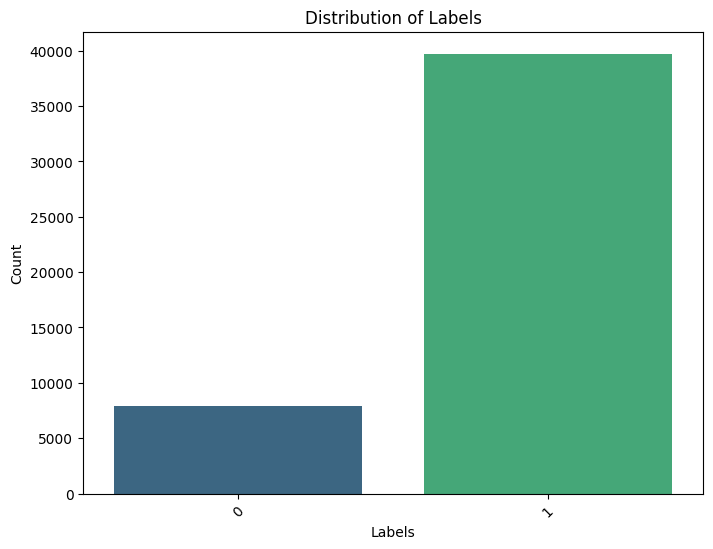

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df2, x='binary_class', palette='viridis')
plt.title("Distribution of Labels")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

After the mapping process, an imbalance occurred where label 0 ("Non-Cyberbullying") is significantly fewer than label 1 ("Cyberbullying").

### **SPLITTING**

In [ ]:
x_bin = df2['cleaned_text']
y_bin = df2['binary_class']

In [ ]:
x_bin_train, x_bin_test, y_bin_train, y_bin_test = train_test_split(x_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

### **IMBALANCE HANDLING**

#### **Without Handling**

In [ ]:
pipeline_bin = pipeline_best

pipeline_bin.fit(x_bin_train, y_bin_train)
y_bin_pred = pipeline_bin.predict(x_bin_test)

print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Binary Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8609334032511798
Binary Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.24      0.36      1589
           1       0.87      0.99      0.92      7946

    accuracy                           0.86      9535
   macro avg       0.82      0.61      0.64      9535
weighted avg       0.85      0.86      0.83      9535



In [ ]:
pipeline_bin = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [ ]:
pipeline_bin.fit(x_bin_train, y_bin_train)
y_bin_pred = pipeline_bin.predict(x_bin_test)

print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Binary Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8446775039328789
Binary Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.30      0.39      1589
           1       0.87      0.95      0.91      7946

    accuracy                           0.84      9535
   macro avg       0.72      0.63      0.65      9535
weighted avg       0.82      0.84      0.82      9535



#### **Weighted**

In [ ]:
pipeline_bin = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(class_weight='balanced',
                                   n_estimators=300, min_samples_leaf=3, min_samples_split=5, random_state=42))
])

pipeline_bin.fit(x_bin_train, y_bin_train)
y_bin_pred = pipeline_bin.predict(x_bin_test)

print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Binary Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8198217094913477
Binary Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.77      0.59      1589
           1       0.95      0.83      0.88      7946

    accuracy                           0.82      9535
   macro avg       0.71      0.80      0.74      9535
weighted avg       0.87      0.82      0.84      9535



In [ ]:
pipeline_bin = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline_bin.fit(x_bin_train, y_bin_train)
y_bin_pred = pipeline_bin.predict(x_bin_test)

print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Binary Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8393287886733088
Binary Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.42      0.47      1589
           1       0.89      0.92      0.91      7946

    accuracy                           0.84      9535
   macro avg       0.71      0.67      0.69      9535
weighted avg       0.83      0.84      0.83      9535



#### **SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline_bin = ImbPipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('smote', SMOTE(random_state=42)),  # Oversampling with SMOTE
    ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=3, min_samples_split=5, random_state=42))
])

pipeline_bin.fit(x_bin_train, y_bin_train)

y_bin_pred = pipeline_bin.predict(x_bin_test)
print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8333508127949659
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.56      0.53      1589
           1       0.91      0.89      0.90      7946

    accuracy                           0.83      9535
   macro avg       0.70      0.72      0.71      9535
weighted avg       0.84      0.83      0.84      9535



In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline_bin = ImbPipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('smote', SMOTE(random_state=42)),  # Oversampling with SMOTE
    ('clf', RandomForestClassifier(random_state=42))
])

pipeline_bin.fit(x_bin_train, y_bin_train)

y_bin_pred = pipeline_bin.predict(x_bin_test)
print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8298898793917148
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.51      0.50      1589
           1       0.90      0.89      0.90      7946

    accuracy                           0.83      9535
   macro avg       0.70      0.70      0.70      9535
weighted avg       0.83      0.83      0.83      9535



#### **Under Sampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline_bin_undersample = ImbPipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('under', RandomUnderSampler(random_state=42)),  # Apply under-sampling to majority class
    ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=3, min_samples_split=5, random_state=42))
])

pipeline_bin_undersample.fit(x_bin_train, y_bin_train)

y_bin_pred = pipeline_bin_undersample.predict(x_bin_test)
print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.784163607760881
Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.92      0.59      1589
           1       0.98      0.76      0.85      7946

    accuracy                           0.78      9535
   macro avg       0.71      0.84      0.72      9535
weighted avg       0.89      0.78      0.81      9535



In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline_bin_undersample = ImbPipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

pipeline_bin_undersample.fit(x_bin_train, y_bin_train)

y_bin_pred = pipeline_bin_undersample.predict(x_bin_test)
print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8446775039328789
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.30      0.39      1589
           1       0.87      0.95      0.91      7946

    accuracy                           0.84      9535
   macro avg       0.72      0.63      0.65      9535
weighted avg       0.82      0.84      0.82      9535



After doing Weighted, SMOTE, and undersampling methods, turnsout that the original (unabalanced) data still achieve the best accuracy

### **PREPROCESSING**

#### **Extract Hashtag**

In [ ]:
x_bin_train_hashtag = x_bin_train.apply(extract_hashtags)
x_bin_test_hashtag = x_bin_test.apply(extract_hashtags)

x_bin_train_pure = x_bin_train.str.replace(r"#\w+", "", regex=True).str.strip()
x_bin_test_pure = x_bin_test.str.replace(r"#\w+", "", regex=True).str.strip()

#### **Tokenization**

In [ ]:
x_bin_train_token =[word_tokenize(i) for i in x_bin_train_pure]
x_bin_test_token =[word_tokenize(i) for i in x_bin_test_pure]

#### **Lemmatization**

In [ ]:
x_bin_train_lemma = [lemmatize_tokens(tokens) for tokens in x_bin_train_token]
x_bin_test_lemma = [lemmatize_tokens(tokens) for tokens in x_bin_test_token]

#### **Stop Words Removal**

In [ ]:
x_bin_train_filtered = [[word for word in sublist if word not in stop_words] for sublist in x_bin_train_lemma]

print(x_bin_train_filtered[0])

['letting', 'commie', 'run', 'human', 'right', 'council', 'like', 'getting', 'high', 'school', 'bully', 'help', 'self', 'esteem', 'issue']


In [ ]:
x_bin_test_filtered = [[word for word in sublist if word not in stop_words] for sublist in x_bin_test_lemma]

print(x_bin_test_filtered[0])

['MENTION', 'like', 'woman', 'refrigerator', 'trope', 'going', 'say', 'comic', 'exist']


#### **Combine Lemmatized Text with Hashtag**

In [ ]:
x_bin_train_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_bin_train_filtered, x_bin_train_hashtag)
]

x_bin_test_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_bin_test_filtered, x_bin_test_hashtag)
]

In [ ]:
print(x_bin_train_combined[0])
print(x_bin_train_combined[1])

letting commie run human right council like getting high school bully help self esteem issue 
matched one girl bullied first high school caused take entire year repeat grade wait ghost lt xoxo 


In [ ]:
print(x_bin_test_combined[0])
print(x_bin_test_combined[1])

MENTION like woman refrigerator trope going say comic exist 
eu ja sofri bullying por causa meninos davidmaurocesarricardo 


#### **After Preprocessing**

In [ ]:
pipeline_bin = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline_bin.fit(x_bin_train_combined, y_bin_train)
y_bin_pred = pipeline_bin.predict(x_bin_test_combined)

print("Binary Classification Accuracy:", accuracy_score(y_bin_test, y_bin_pred))
print("Binary Classification Report:\n", classification_report(y_bin_test, y_bin_pred))

Binary Classification Accuracy: 0.8464604090194022
Binary Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.54      0.54      1589
           1       0.91      0.91      0.91      7946

    accuracy                           0.85      9535
   macro avg       0.72      0.73      0.72      9535
weighted avg       0.85      0.85      0.85      9535



### **MODELING**

#### **Random Forest**

In [ ]:
from sklearn.model_selection import GridSearchCV

bin_pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 300, 500],
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__min_samples_split': [2, 5, 10],
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    bin_pipeline_rf,
    param_grid,
    scoring='accuracy',
    cv=3,  # Cross-validation folds
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_bin_train_combined, y_bin_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_bin_pred_rf = best_model.predict(x_bin_test_combined)
print("Accuracy on test data:", accuracy_score(y_bin_test, y_bin_pred_rf))
print("Classification Report on test data:\n", classification_report(y_bin_test, y_bin_pred_rf))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best cross-validation score:  0.8703984971756381
Accuracy on test data: 0.8706869428421604
Classification Report on test data:
               precision    recall  f1-score   support

           0       0.71      0.37      0.49      1589
           1       0.89      0.97      0.93      7946

    accuracy                           0.87      9535
   macro avg       0.80      0.67      0.71      9535
weighted avg       0.86      0.87      0.85      9535



In [ ]:
joblib.dump(best_model, 'TC_best_rf_model.pkl')
print("Model saved as TC_best_rf_model.pkl")

Model saved as TC_best_rf_model.pkl


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TC_best_rf_model.pkl'

best_bin_model_rf = joblib.load(model_path)
print("Model loaded successfully")

y_bin_pred_rf = best_bin_model_rf.predict(x_bin_test_combined)
print("Accuracy on test data with loaded model:", accuracy_score(y_bin_test, y_bin_pred_rf))
print("Classification Report:", classification_report(y_bin_test, y_bin_pred_rf))

Model loaded successfully
Accuracy on test data with loaded model: 0.8706869428421604
Classification Report:               precision    recall  f1-score   support

           0       0.71      0.37      0.49      1589
           1       0.89      0.97      0.93      7946

    accuracy                           0.87      9535
   macro avg       0.80      0.67      0.71      9535
weighted avg       0.86      0.87      0.85      9535



#### **SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
import joblib

def train_and_evaluate_svm(x_train, y_train, x_test, y_test, params):
    global best_accuracy, best_model, best_tfidf
    tfidf = TfidfVectorizer(max_features=5000)
    x_train_tfidf = tfidf.fit_transform(x_train)
    x_test_tfidf = tfidf.transform(x_test)

    model = SVC(**params)
    model.fit(x_train_tfidf, y_train)

    y_pred = model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-" * 80)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_tfidf = tfidf

best_accuracy = 0
best_model = None
best_tfidf = None

svm_models_params = [
    {'C': 1.0, 'kernel': 'linear', 'tol': 1e-4},
    {'C': 10.0, 'kernel': 'rbf', 'tol': 1e-4, 'gamma': 0.1},
    {'C': 0.5, 'kernel': 'poly', 'tol': 1e-3, 'gamma': 'scale', 'degree': 3}
]

for params in svm_models_params:
    train_and_evaluate_svm(x_bin_train_combined, y_bin_train, x_bin_test_combined, y_bin_test, params)

Parameters: {'C': 1.0, 'kernel': 'linear', 'tol': 0.0001}
Accuracy: 0.8736234923964342
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.38      0.50      1589
           1       0.89      0.97      0.93      7946

    accuracy                           0.87      9535
   macro avg       0.81      0.67      0.71      9535
weighted avg       0.86      0.87      0.86      9535

--------------------------------------------------------------------------------
Parameters: {'C': 10.0, 'kernel': 'rbf', 'tol': 0.0001, 'gamma': 0.1}
Accuracy: 0.8710015731515469
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.43      0.52      1589
           1       0.89      0.96      0.93      7946

    accuracy                           0.87      9535
   macro avg       0.79      0.69      0.72      9535
weighted avg       0.86      0.87      0.86      9535

---------------------------------

In [ ]:
joblib.dump({'model': best_model, 'tfidf': best_tfidf}, 'TC_best_svm_model.pkl')
print(f"Best model saved with accuracy: {best_accuracy}")

Best model saved with accuracy: 0.8736234923964342


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TC_best_svm_model.pkl'
svm_bin_loaded_data = joblib.load(model_path)
best_bin_model_svm = svm_bin_loaded_data['model']
tfidf_bin_svm = svm_bin_loaded_data['tfidf']
print("Model loaded successfully")

x_test_tfidf_loaded = tfidf_bin_svm.transform(x_bin_test_combined)
y_bin_pred_svm = best_bin_model_svm.predict(x_test_tfidf_loaded)
print("Accuracy on test data with loaded model:", accuracy_score(y_bin_test, y_bin_pred_svm))
print("Classification Report on test data:\n", classification_report(y_bin_test, y_bin_pred_svm))

Model loaded successfully
Accuracy on test data with loaded model: 0.8736234923964342
Classification Report on test data:
               precision    recall  f1-score   support

           0       0.74      0.38      0.50      1589
           1       0.89      0.97      0.93      7946

    accuracy                           0.87      9535
   macro avg       0.81      0.67      0.71      9535
weighted avg       0.86      0.87      0.86      9535



#### **XGBoost**


In [ ]:
import joblib
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

def train_and_evaluate_no_pipeline(x_train, y_train, x_test, y_test, params):
    global best_accuracy, best_model, best_tfidf
    tfidf = TfidfVectorizer(max_features=5000)
    x_train_tfidf = tfidf.fit_transform(x_train)
    x_test_tfidf = tfidf.transform(x_test)

    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **params)
    model.fit(x_train_tfidf, y_train)

    y_pred = model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-" * 80)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_tfidf = tfidf

best_accuracy = 0
best_model = None
best_tfidf = None

models_params = [
    {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 1.0},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.9}
]

for params in models_params:
    train_and_evaluate_no_pipeline(x_bin_train_combined, y_bin_train, x_bin_test_combined, y_bin_test, params)

Parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 1.0}
Accuracy: 0.8598846355532249
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.28      0.40      1589
           1       0.87      0.98      0.92      7946

    accuracy                           0.86      9535
   macro avg       0.79      0.63      0.66      9535
weighted avg       0.84      0.86      0.83      9535

--------------------------------------------------------------------------------
Parameters: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8}
Accuracy: 0.8736234923964342
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.37      0.49      1589
           1       0.89      0.97      0.93      7946

    accuracy                           0.87      9535
   macro avg       0.81      0.67      

In [ ]:
joblib.dump({'model': best_model, 'tfidf': best_tfidf}, 'TC_best_xgboost_model.pkl')
print(f"Best model saved with accuracy: {best_accuracy} as TC_best_xgboost_model.pkl")

Best model saved with accuracy: 0.8738332459360252 as TC_best_xgboost_model.pkl


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TC_best_xgboost_model.pkl'
xgb_saved_data = joblib.load(model_path)
best_bin_model_xgb = xgb_saved_data['model']
tfidf_bin_xgb = xgb_saved_data['tfidf']
print("Model loaded successfully")

x_test_tfidf_loaded = tfidf_bin_xgb.transform(x_bin_test_combined)
y_bin_pred_xgb = best_bin_model_xgb.predict(x_test_tfidf_loaded)
print("Accuracy on test data with loaded model:", accuracy_score(y_bin_test, y_bin_pred_xgb))
print("Classification Report:\n", classification_report(y_bin_test, y_bin_pred_xgb))

Model loaded successfully
Accuracy on test data with loaded model: 0.8738332459360252
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.37      0.49      1589
           1       0.89      0.97      0.93      7946

    accuracy                           0.87      9535
   macro avg       0.81      0.67      0.71      9535
weighted avg       0.86      0.87      0.86      9535



In [ ]:
TS_bin_report_model = classification_report(y_bin_test, y_bin_pred_xgb, output_dict=True)

In [ ]:
accuracy_bin_rf = accuracy_score(y_bin_test, y_bin_pred_rf)
accuracy_bin_xgb = accuracy_score(y_bin_test, y_bin_pred_xgb)
accuracy_bin_svm = accuracy_score(y_bin_test, y_bin_pred_svm)

accuracy_data = {
    'Model': ['Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [accuracy_bin_rf, accuracy_bin_xgb, accuracy_bin_svm]
}

accuracy_df = pd.DataFrame(accuracy_data)
accuracy_df

,Model,Accuracy
0,Random Forest,0.870687
1,XGBoost,0.873833
2,SVM,0.873623


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TC_best_xgboost_model.pkl'
TS_bin_best_model =  joblib.load(model_path)

For Two-Step-Binary Classification's model, XGBoost also achieve the best or highest accuracy.





## **MULTI-CLASS CLASSIFICATION (CYBERBULLYING CATEGORIES)**

### **DATA PREPARATION**

In [ ]:
df3 = df.copy()

In [ ]:
df3.head()

,tweet_text,cyberbullying_type,text_length,word_count,cleaned_text
0,"In other words #katandandre, your food was cra...",0,61,9,in other words #katandandre your food was crap...
1,Why is #aussietv so white? #MKR #theblock #ImA...,0,115,14,why is #aussietv so white #mkr #theblock #imac...
2,@XochitlSuckkks a classy whore? Or more red ve...,0,60,9,MENTION a classy whore or more red velvet cupc...
3,"@Jason_Gio meh. :P thanks for the heads up, b...",0,103,18,MENTION meh p thanks for the heads up but not ...
4,@RudhoeEnglish This is an ISIS account pretend...,0,103,18,MENTION this is an isis account pretending to ...


In [ ]:
df3 = df3[df3['cyberbullying_type'] != 0]

We drop the 'not_cyberbullying' class because we only want to classify the types of cyberbullying.

In [ ]:
df3['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
1,7998
2,7992
3,7970
4,7961
5,7810


### **LABEL DISTRIBUTION**

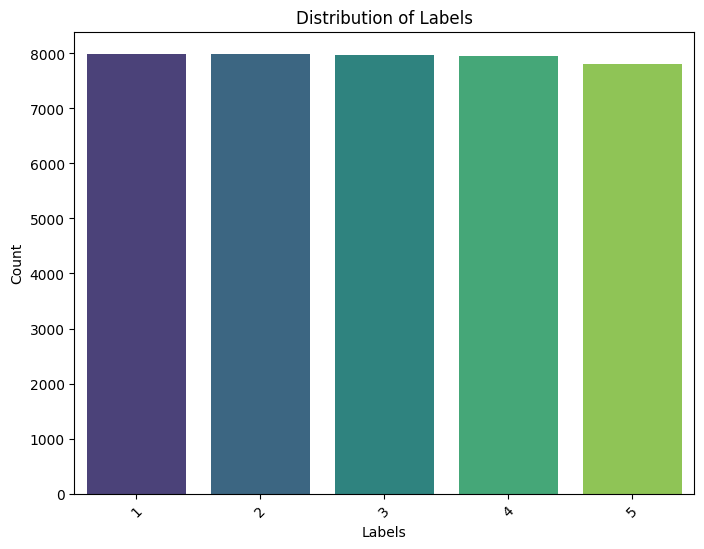

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df3, x='cyberbullying_type', palette='viridis')
plt.title("Distribution of Labels")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The distribution of the labels is balanced

### **SPLITTING**

In [ ]:
x_mul = df3['cleaned_text']
y_mul = df3['cyberbullying_type']

In [ ]:
x_mul_train, x_mul_test, y_mul_train, y_mul_test = train_test_split(x_mul, y_mul, test_size=0.2, random_state=42, stratify=y_mul)

### **PREPROCESSING**

#### **Extract Hashtag**

In [ ]:
x_mul_train_hashtag = x_mul_train.apply(extract_hashtags)
x_mul_test_hashtag = x_mul_test.apply(extract_hashtags)

x_mul_train_pure = x_mul_train.str.replace(r"#\w+", "", regex=True).str.strip()
x_mul_test_pure = x_mul_test.str.replace(r"#\w+", "", regex=True).str.strip()

#### **Tokenization**

In [ ]:
x_mul_train_token =[word_tokenize(i) for i in x_mul_train_pure]
x_mul_test_token =[word_tokenize(i) for i in x_mul_test_pure]

#### **Lemmatization**

In [ ]:
x_mul_train_lemma = [lemmatize_tokens(tokens) for tokens in x_mul_train_token]
x_mul_test_lemma = [lemmatize_tokens(tokens) for tokens in x_mul_test_token]

#### **Stop Words Removal**

In [ ]:
x_mul_train_filtered = [[word for word in sublist if word not in stop_words] for sublist in x_mul_train_lemma]

print(x_mul_train_filtered[0])

['MENTION', 'MENTION', 'might', 'need', 'lube', 'tip', 'wider', 'hip']


In [ ]:
x_mul_test_filtered = [[word for word in sublist if word not in stop_words] for sublist in x_mul_test_lemma]

print(x_mul_test_filtered[0])

['doe', 'elementary', 'school', 'bully', 'look', 'like']


#### **Combine Lemmatized Text with Hashtag**

In [ ]:
x_mul_train_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_mul_train_filtered, x_mul_train_hashtag)
]

x_mul_test_combined = [
    " ".join(lemma_tokens) + " " + (hashtag if hashtag else "")
    for lemma_tokens, hashtag in zip(x_mul_test_filtered, x_mul_test_hashtag)
]

In [ ]:
print(x_mul_train_combined[0])
print(x_mul_train_combined[1])

MENTION MENTION might need lube tip wider hip 
see gf week real stuff #mkr #boring #imdone


In [ ]:
print(x_mul_test_combined[0])
print(x_mul_test_combined[1])

doe elementary school bully look like 
isi follow religion terrorist america found ruin name muslim better google bible muslim quran u realize peacfull religion 


In [ ]:
pipeline_mul = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline_mul.fit(x_mul_train_combined, y_mul_train)
y_mul_pred = pipeline_mul.predict(x_mul_test_combined)

print("Multi Classification Accuracy:", accuracy_score(y_mul_test, y_mul_pred))
print("Multi Classification Report:\n", classification_report(y_mul_test, y_mul_pred))

Multi Classification Accuracy: 0.9452623631559078
Multi Classification Report:
               precision    recall  f1-score   support

           1       0.99      0.97      0.98      1600
           2       0.99      0.99      0.99      1599
           3       0.92      0.86      0.89      1594
           4       0.99      0.99      0.99      1592
           5       0.84      0.92      0.88      1562

    accuracy                           0.95      7947
   macro avg       0.95      0.95      0.95      7947
weighted avg       0.95      0.95      0.95      7947



### **MODELING**

#### **Random Forest**

In [ ]:
from sklearn.model_selection import GridSearchCV

mul_pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 300, 500],
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__min_samples_split': [2, 5, 10],
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    mul_pipeline_rf,
    param_grid,
    scoring='accuracy',
    cv=3,  # Cross-validation folds
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_mul_train_combined, y_mul_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_mul_pred_rf = best_model.predict(x_mul_test_combined)
print("Accuracy on test data:", accuracy_score(y_mul_test, y_mul_pred_rf))
print("Classification Report on test data:\n", classification_report(y_mul_test, y_mul_pred_rf))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Best cross-validation score:  0.9447205477119388
Accuracy on test data: 0.9448848622121555
Classification Report on test data:
               precision    recall  f1-score   support

           1       0.99      0.97      0.98      1600
           2       0.99      0.99      0.99      1599
           3       0.92      0.86      0.89      1594
           4       0.99      0.99      0.99      1592
           5       0.84      0.92      0.88      1562

    accuracy                           0.94      7947
   macro avg       0.95      0.94      0.94      7947
weighted avg       0.95      0.94      0.95      7947



In [ ]:
joblib.dump(best_model, 'TCmul_best_rf_model.pkl')
print("Model saved as TCmul_best_rf_model.pkl")

Model saved as TCmul_best_rf_model.pkl


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TCmul_best_rf_model.pkl'

best_mul_model_rf = joblib.load(model_path)
print("Model loaded successfully")

y_mul_pred_rf = best_mul_model_rf.predict(x_mul_test_combined)
print("Accuracy on test data with loaded model:", accuracy_score(y_mul_test, y_mul_pred_rf))
print("Classification Report:", classification_report(y_mul_test, y_mul_pred_rf))

Model loaded successfully
Accuracy on test data with loaded model: 0.9448848622121555
Classification Report:               precision    recall  f1-score   support

           1       0.99      0.97      0.98      1600
           2       0.99      0.99      0.99      1599
           3       0.92      0.86      0.89      1594
           4       0.99      0.99      0.99      1592
           5       0.84      0.92      0.88      1562

    accuracy                           0.94      7947
   macro avg       0.95      0.94      0.94      7947
weighted avg       0.95      0.94      0.95      7947



#### **SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
import joblib

def train_and_evaluate_svm(x_train, y_train, x_test, y_test, params):
    global best_accuracy, best_model, best_tfidf
    tfidf = TfidfVectorizer(max_features=5000)
    x_train_tfidf = tfidf.fit_transform(x_train)
    x_test_tfidf = tfidf.transform(x_test)

    model = SVC(**params)
    model.fit(x_train_tfidf, y_train)

    y_pred = model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-" * 80)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_tfidf = tfidf

best_accuracy = 0
best_model = None
best_tfidf = None

svm_models_params = [
    {'C': 1.0, 'kernel': 'linear', 'tol': 1e-4},
    {'C': 10.0, 'kernel': 'rbf', 'tol': 1e-4, 'gamma': 0.1},
    {'C': 0.5, 'kernel': 'poly', 'tol': 1e-3, 'gamma': 'scale', 'degree': 3}
]

for params in svm_models_params:
    train_and_evaluate_svm(x_mul_train_combined, y_mul_train, x_mul_test_combined, y_mul_test, params)

Parameters: {'C': 1.0, 'kernel': 'linear', 'tol': 0.0001}
Accuracy: 0.9455140304517428
Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.97      0.98      1600
           2       0.99      0.99      0.99      1599
           3       0.94      0.86      0.90      1594
           4       0.99      0.98      0.99      1592
           5       0.84      0.93      0.88      1562

    accuracy                           0.95      7947
   macro avg       0.95      0.95      0.95      7947
weighted avg       0.95      0.95      0.95      7947

--------------------------------------------------------------------------------
Parameters: {'C': 10.0, 'kernel': 'rbf', 'tol': 0.0001, 'gamma': 0.1}
Accuracy: 0.9457656977475777
Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.97      0.98      1600
           2       0.99      0.98      0.99      1599
           3       0.93      0.87  

In [ ]:
joblib.dump({'model': best_model, 'tfidf': best_tfidf}, 'TCmul_best_svm_model.pkl')
print(f"Best model saved with accuracy: {best_accuracy}")

Best model saved with accuracy: 0.9457656977475777


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TCmul_best_svm_model.pkl'
svm_mul_loaded_data = joblib.load(model_path)
best_mul_model_svm = svm_mul_loaded_data['model']
tfidf_mul_svm = svm_mul_loaded_data['tfidf']
print("Model loaded successfully")

x_test_tfidf_loaded = tfidf_mul_svm.transform(x_mul_test_combined)
y_mul_pred_svm = best_mul_model_svm.predict(x_test_tfidf_loaded)
print("Accuracy on test data with loaded model:", accuracy_score(y_mul_test, y_mul_pred_svm))
print("Classification Report on test data:\n", classification_report(y_mul_test, y_mul_pred_svm))

Model loaded successfully
Accuracy on test data with loaded model: 0.9457656977475777
Classification Report on test data:
               precision    recall  f1-score   support

           1       0.99      0.97      0.98      1600
           2       0.99      0.98      0.99      1599
           3       0.93      0.87      0.90      1594
           4       0.99      0.98      0.98      1592
           5       0.85      0.92      0.88      1562

    accuracy                           0.95      7947
   macro avg       0.95      0.95      0.95      7947
weighted avg       0.95      0.95      0.95      7947



In [ ]:
TS_mul_report_model = classification_report(y_mul_test, y_mul_pred_svm, output_dict=True)

#### **XGBoost**

In [ ]:
mapping = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
y_mul_train_xgb = y_mul_train.map(mapping)
y_mul_test_xgb = y_mul_test.map(mapping)

In [ ]:
import joblib
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

def train_and_evaluate_no_pipeline(x_train, y_train, x_test, y_test, params):
    global best_accuracy, best_model, best_tfidf

    tfidf = TfidfVectorizer(max_features=5000)
    x_train_tfidf = tfidf.fit_transform(x_train)
    x_test_tfidf = tfidf.transform(x_test)

    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **params)
    model.fit(x_train_tfidf, y_train)

    y_pred = model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-" * 80)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_tfidf = tfidf

best_accuracy = 0
best_model = None
best_tfidf = None

models_params = [
    {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 1.0},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.9}
]

for params in models_params:
    train_and_evaluate_no_pipeline(x_mul_train_combined, y_mul_train_xgb, x_mul_test_combined, y_mul_test_xgb, params)

Parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 1.0}
Accuracy: 0.9336856675475022
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1600
           1       0.99      0.99      0.99      1599
           2       0.93      0.84      0.88      1594
           3       1.00      0.98      0.99      1592
           4       0.78      0.93      0.85      1562

    accuracy                           0.93      7947
   macro avg       0.94      0.93      0.93      7947
weighted avg       0.94      0.93      0.93      7947

--------------------------------------------------------------------------------
Parameters: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8}
Accuracy: 0.9438781930288159
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0

In [ ]:
joblib.dump({'model': best_model, 'tfidf': best_tfidf}, 'TCmul_best_xgboost_model.pkl')
print(f"Best model saved with accuracy: {best_accuracy} as TCmul_best_xgboost_model.pkl")

Best model saved with accuracy: 0.9441298603246508 as TCmul_best_xgboost_model.pkl


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TCmul_best_xgboost_model.pkl'
xgb_saved_data = joblib.load(model_path)
best_mul_model_xgb = xgb_saved_data['model']
tfidf_mul_xgb = xgb_saved_data['tfidf']
print("Model loaded successfully")

x_test_tfidf_loaded = tfidf_mul_xgb.transform(x_mul_test_combined)
y_mul_pred_xgb = best_mul_model_xgb.predict(x_test_tfidf_loaded)
print("Accuracy on test data with loaded model:", accuracy_score(y_mul_test_xgb, y_mul_pred_xgb))
print("Classification Report:\n", classification_report(y_mul_test_xgb, y_mul_pred_xgb))

Model loaded successfully
Accuracy on test data with loaded model: 0.9441298603246508
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1600
           1       0.99      0.99      0.99      1599
           2       0.93      0.87      0.90      1594
           3       0.99      0.99      0.99      1592
           4       0.83      0.93      0.87      1562

    accuracy                           0.94      7947
   macro avg       0.95      0.94      0.94      7947
weighted avg       0.95      0.94      0.94      7947



In [ ]:
accuracy_mul_rf = accuracy_score(y_mul_test, y_mul_pred_rf)
accuracy_mul_xgb = accuracy_score(y_mul_test_xgb, y_mul_pred_xgb)
accuracy_mul_svm = accuracy_score(y_mul_test, y_mul_pred_svm)

accuracy_data = {
    'Model': ['Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [accuracy_mul_rf, accuracy_mul_xgb, accuracy_mul_svm]
}

accuracy_df = pd.DataFrame(accuracy_data)
accuracy_df

,Model,Accuracy
0,Random Forest,0.944885
1,XGBoost,0.944130
2,SVM,0.945766


In [ ]:
model_path = '/content/drive/My Drive/AOL_TextMining/TCmul_best_svm_model.pkl'
TS_mul_best_model =  joblib.load(model_path)

For Two-Step-Multilass Classification's model, SVM achieve the best or highest accuracy.

## **EVALUATION**

The evaluation here compares one-step and two-step method.

In [ ]:
from google.colab import files

# Save file to .json format
file_path = "f_reports.json"
with open(file_path, 'w') as f:
    json.dump({
        "OS_report_model": OS_report_model,
        "TS_bin_report_model": TS_bin_report_model,
        "TS_mul_report_model": TS_mul_report_model
    }, f, indent=4)

files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
file_path = '/content/drive/My Drive/AOL_TextMining/f_reports.json'
with open(file_path, 'r') as f:
    data = json.load(f)

# load the data
print(json.dumps(data, indent=4))

{
    "OS_report_model": {
        "0": {
            "precision": 0.6935483870967742,
            "recall": 0.460037759597231,
            "f1-score": 0.553159288687098,
            "support": 1589.0
        },
        "1": {
            "precision": 0.9734455958549223,
            "recall": 0.939375,
            "f1-score": 0.9561068702290076,
            "support": 1600.0
        },
        "2": {
            "precision": 0.9929396662387676,
            "recall": 0.9680851063829787,
            "f1-score": 0.9803548795944234,
            "support": 1598.0
        },
        "3": {
            "precision": 0.9199726402188783,
            "recall": 0.8437892095357591,
            "f1-score": 0.8802356020942408,
            "support": 1594.0
        },
        "4": {
            "precision": 0.9955555555555555,
            "recall": 0.9849246231155779,
            "f1-score": 0.9902115566782443,
            "support": 1592.0
        },
        "5": {
            "precision": 0.56447480

In [ ]:
OS_report_model = data["OS_report_model"] # One-Step
TS_bin_report_model = data["TS_bin_report_model"] # Two-step-binary
TS_mul_report_model = data["TS_mul_report_model"] # Two-step-multiclass

In [ ]:
print(OS_report_model)
print("-" * 80)
print(TS_bin_report_model)
print("-" * 80)
print(TS_mul_report_model)

{'0': {'precision': 0.6935483870967742, 'recall': 0.460037759597231, 'f1-score': 0.553159288687098, 'support': 1589.0}, '1': {'precision': 0.9734455958549223, 'recall': 0.939375, 'f1-score': 0.9561068702290076, 'support': 1600.0}, '2': {'precision': 0.9929396662387676, 'recall': 0.9680851063829787, 'f1-score': 0.9803548795944234, 'support': 1598.0}, '3': {'precision': 0.9199726402188783, 'recall': 0.8437892095357591, 'f1-score': 0.8802356020942408, 'support': 1594.0}, '4': {'precision': 0.9955555555555555, 'recall': 0.9849246231155779, 'f1-score': 0.9902115566782443, 'support': 1592.0}, '5': {'precision': 0.5644748078565329, 'recall': 0.8463508322663252, 'f1-score': 0.6772540983606558, 'support': 1562.0}, 'accuracy': 0.8406921866806503, 'macro avg': {'precision': 0.8566561088035719, 'recall': 0.8404270884829786, 'f1-score': 0.8395537159406117, 'support': 9535.0}, 'weighted avg': {'precision': 0.8578237451430982, 'recall': 0.8406921866806503, 'f1-score': 0.8403493916404224, 'support': 9

In [ ]:
report_model1 = TS_bin_report_model
report_model2 = OS_report_model

# Class 0
precision_model1_class0 = report_model1['0']['precision']
recall_model1_class0 = report_model1['0']['recall']
f1_model1_class0 = report_model1['0']['f1-score']

precision_model2_class0 = report_model2['0']['precision']
recall_model2_class0 = report_model2['0']['recall']
f1_model2_class0 = report_model2['0']['f1-score']

# Class 1 in Two-Step Binary
precision_model1_class1 = report_model1['1']['precision']
recall_model1_class1 = report_model1['1']['recall']
f1_model1_class1 = report_model1['1']['f1-score']

# Average metrics for class 1 to 5 di Model 2
classes = ['1', '2', '3', '4', '5']
precision_model2_avg = np.mean([report_model2[cls]['precision'] for cls in classes])
recall_model2_avg = np.mean([report_model2[cls]['recall'] for cls in classes])
f1_model2_avg = np.mean([report_model2[cls]['f1-score'] for cls in classes])

In [ ]:
# Comparison data for class 0
comparison_class0 = {
    "Metric": ["Precision", "Recall", "F1-Score"],
    "One Step (Class 0)": [precision_model2_class0, recall_model2_class0, f1_model2_class0],
    "Two Step - Binary (Class 0)": [precision_model1_class0, recall_model1_class0, f1_model1_class0],
}

# Comparsion data for class 1 and the average of class 1-5
comparison_class1_avg = {
    "Metric": ["Precision", "Recall", "F1-Score"],
    "One Step (Class 1)": [precision_model2_avg, recall_model2_avg, f1_model2_avg],
    "Two Step - Binary (AVG Class 1-5)": [precision_model1_class1, recall_model1_class1, f1_model1_class1]
}

df_compare_bin_0 = pd.DataFrame(comparison_class0)
df_compare_bin_1 = pd.DataFrame(comparison_class1_avg)

In [ ]:
print("Comparison of Model Performance for NOT_CYBERBULLYING:")
df_compare_bin_0.transpose()

Comparison of Model Performance for NOT_CYBERBULLYING:


,0,1,2
Metric,Precision,Recall,F1-Score
One Step (Class 0),0.693548,0.460038,0.553159
Two Step - Binary (Class 0),0.744304,0.370044,0.494325


Here, the One-Step method is more suitable when higher recall is required to capture more instances of Class 0, while the Two-Step Binary approach is preferable for achieving higher precision and minimizing false positives.

In [ ]:
print("Comparison of Model Performance for CYBERBULLYING:")
df_compare_bin_1.transpose()

Comparison of Model Performance for CYBERBULLYING:


,0,1,2
Metric,Precision,Recall,F1-Score
One Step (Class 1),0.889278,0.916505,0.896833
Two Step - Binary (AVG Class 1-5),0.885535,0.974578,0.927925


Based on the evaluation, the Two-Step Binary approach outperforms in terms of overall F1-Score and recall across multiple classes (Class 1-5), making it a more balanced choice for handling diverse label distributions, while the One-Step approach demonstrates slightly better precision for Class 1 specifically.

In [ ]:
classes = ['1', '2', '3', '4', '5']

# Model 1 (TS_mul_report_model)
metrics_model1 = {
    cls: {
        "Precision": TS_mul_report_model[cls]['precision'],
        "Recall": TS_mul_report_model[cls]['recall'],
        "F1-Score": TS_mul_report_model[cls]['f1-score']
    }
    for cls in classes
}

# Model 2 (OS_report_model)
metrics_model2 = {
    cls: {
        "Precision": OS_report_model[cls]['precision'],
        "Recall": OS_report_model[cls]['recall'],
        "F1-Score": OS_report_model[cls]['f1-score']
    }
    for cls in classes
}

dfs = {}
for cls in classes:
    data = {
        "Metric": ["Precision", "Recall", "F1-Score"],
        "One Step": [
            metrics_model2[cls]["Precision"],
            metrics_model2[cls]["Recall"],
            metrics_model2[cls]["F1-Score"]
        ],
        "Two Step - Multi": [
            metrics_model1[cls]["Precision"],
            metrics_model1[cls]["Recall"],
            metrics_model1[cls]["F1-Score"]
        ]
    }
    dfs[f"Class {cls}"] = pd.DataFrame(data)

In [ ]:
print("Comparison of Model Performance for CLASS 1 - RELIGION:")
dfs["Class 1"].transpose()

Comparison of Model Performance for CLASS 1 - RELIGION:


,0,1,2
Metric,Precision,Recall,F1-Score
One Step,0.973446,0.939375,0.956107
Two Step - Multi,0.986624,0.968125,0.977287


The comparison indicates that the Two-Step Multi approach performs better for Class 1 - Religion, achieving higher precision (0.986624), recall (0.968125), and F1-score (0.977287) compared to the One-Step approach, which has slightly lower metrics across all measures.

In [ ]:
print("Comparison of Model Performance for CLASS 2 - AGE:")
dfs["Class 2"].transpose()

Comparison of Model Performance for CLASS 2 - AGE:


,0,1,2
Metric,Precision,Recall,F1-Score
One Step,0.99294,0.968085,0.980355
Two Step - Multi,0.986842,0.984991,0.985915


For Class 2 - Age, the Two-Step Multi approach outperforms the One-Step approach with a higher F1-score (0.985915 vs. 0.980355) and better recall (0.984991 vs. 0.968085), despite slightly lower precision.

In [ ]:
print("Comparison of Model Performance for CLASS 3 - GENDER:")
dfs["Class 3"].transpose()

Comparison of Model Performance for CLASS 3 - GENDER:


,0,1,2
Metric,Precision,Recall,F1-Score
One Step,0.919973,0.843789,0.880236
Two Step - Multi,0.930013,0.867001,0.897403


For Class 3 - Gender, the Two-Step Multi approach outperforms the One-Step approach across all metrics, with higher precision (0.930013), recall (0.867001), and F1-score (0.89740), indicating a more accurate and reliable performance.

In [ ]:
print("Comparison of Model Performance for CLASS 4 - ETHNICITY:")
dfs["Class 4"].transpose()

Comparison of Model Performance for CLASS 4 - ETHNICITY:


,0,1,2
Metric,Precision,Recall,F1-Score
One Step,0.995556,0.984925,0.990212
Two Step - Multi,0.986146,0.983668,0.984906


For Class 4 - Ethnicity, the One-Step approach outperforms the Two-Step Multi approach across all metrics, achieving higher precision (0.995556 vs. 0.986146), recall (0.984925 vs. 0.983668), and F1-score (0.990212 vs. 0.984906), making it the better choice for this class.

In [ ]:
print("Comparison of Model Performance for CLASS 5 - OTHER_CYBERBULLYING:")
dfs["Class 5"].transpose()

Comparison of Model Performance for CLASS 5 - OTHER_CYBERBULLYING:


,0,1,2
Metric,Precision,Recall,F1-Score
One Step,0.564475,0.846351,0.677254
Two Step - Multi,0.845929,0.924456,0.883451


For Class 5 - Other_Cyberbullying, the Two-Step Multi approach significantly outperforms the One-Step approach in all metrics, with higher precision (0.845929 vs. 0.564475), recall (0.924456 vs. 0.846351), and F1-score (0.883451 vs. 0.677254), making it the clearly better choice for this class.

In [ ]:
accuracy_TS_bin = TS_bin_report_model['accuracy']
accuracy_TS_mul = TS_mul_report_model['accuracy']
average_accuracy = (accuracy_TS_bin + accuracy_TS_mul) / 2

accuracy_OS_report = OS_report_model['accuracy']

comparison_accuracy = {
    "Metric": ["One Step", "Two Step"],
    "Value": [accuracy_OS_report, average_accuracy]
}

df_accuracy_comparison = pd.DataFrame(comparison_accuracy)

df_accuracy_comparison

,Metric,Value
0,One Step,0.840692
1,Two Step,0.909799


The accuracy comparison indicates that the Two-Step approach achieves a significantly higher average accuracy (0.909799) compared to the One-Step approach (0.840692). This suggests that the Two-Step method is more effective in handling the classification tasks overall. Therefore, for applications prioritizing accuracy, the Two-Step approach is the more reliable choice.

## **CONCLUSION**

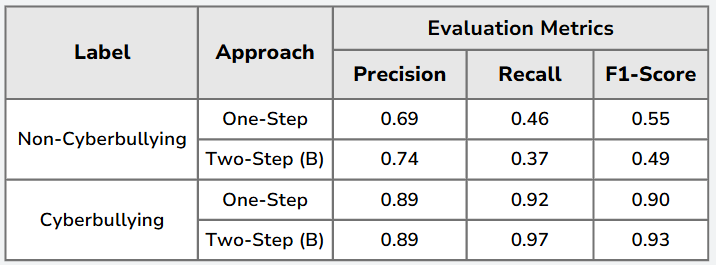

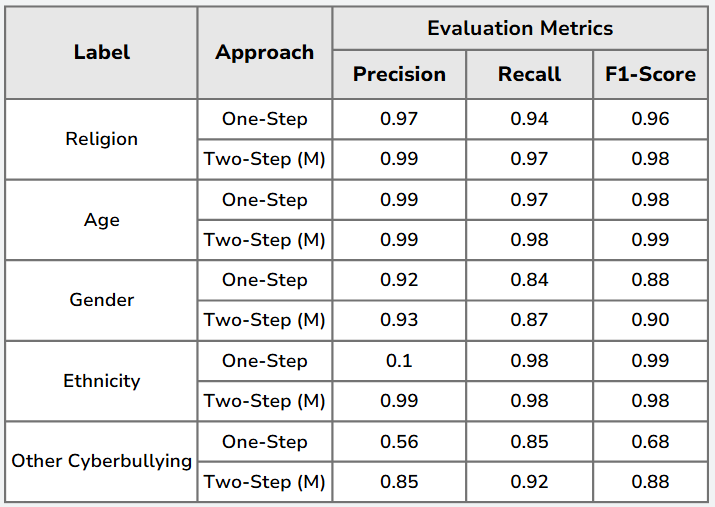

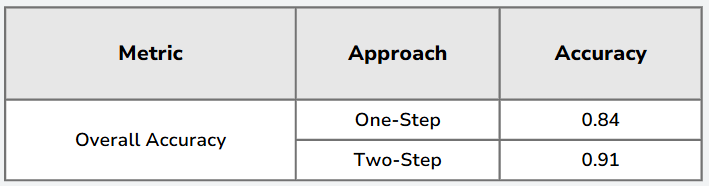


Based on the performance comparisons across various metrics, the Two-Step approach generally outperforms the One-Step approach in terms of F1-score, recall, and overall accuracy, especially for classes with more complex label distributions or those requiring better balance between precision and recall. While the One-Step approach demonstrates slightly higher precision for some classes, the Two-Step approach consistently provides better recall and higher overall F1-scores, particularly in handling diverse or imbalanced data. In conclusion, the Two-Step approach proves to be more reliable and effective for achieving better model performance, making it the preferred choice for most classification tasks in this evaluation.